# YOLO-PCB 제출용 Colab 실험 노트북

본 노트북은 논문 **A deep context learning based PCB defect detection model with anomalous trend alarming system**의 공개 저장소 `JiaLim98/YOLO-PCB`를 사용하여 PCB 결함 검출 inference를 재현하는 제출용 코드입니다.

실행 전 Colab에서 **런타임 → 런타임 유형 변경 → GPU**를 선택하세요.

## 8.1 GPU 확인

In [1]:
import torch
import sys

print("Python executable:", sys.executable)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU가 잡히지 않았습니다. Colab에서 런타임 유형을 GPU로 바꾸세요.")

Python executable: /usr/bin/python3
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU name: Tesla T4


## 8.2 YOLO-PCB 저장소 clone 및 패키지 설치

In [2]:
%cd /content

# 기존 폴더가 있으면 삭제 후 다시 clone
!rm -rf YOLO-PCB
!git clone https://github.com/JiaLim98/YOLO-PCB.git

%cd /content/YOLO-PCB

# Colab 기본 환경과 충돌하지 않도록 setuptools 버전을 제한
!python -m pip install -q "setuptools<82" "jedi>=0.16" wheel
!python -m pip install -q opencv-python matplotlib pandas pyyaml tqdm pillow "thop==0.1.1.post2209072238"

# 설치 확인
import importlib.metadata as metadata
import torch
import thop

print("setuptools version:", metadata.version("setuptools"))
print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("thop import 성공:", thop.__file__)

/content
Cloning into 'YOLO-PCB'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 129 (delta 13), reused 2 (delta 2), pack-reused 111 (from 1)
Receiving objects: 100% (129/129), 48.20 MiB | 17.69 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/YOLO-PCB
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 80.3 MB/s eta 0:00:00
setuptools version: 75.2.0
torch version: 2.11.0+cu128
CUDA available: True
thop import 성공: /usr/local/lib/python3.12/dist-packages/thop/__init__.py


## 8.3 PyTorch / Python 3.12 호환 패치

In [3]:
from pathlib import Path
import re

%cd /content/YOLO-PCB

# 1) PyTorch 2.6 이상 torch.load weights_only 기본값 변경 대응
exp_path = Path("/content/YOLO-PCB/models/experimental.py")
exp_text = exp_path.read_text()

old = "torch.load(w, map_location=map_location)['model'].float().fuse().eval()"
new = "torch.load(w, map_location=map_location, weights_only=False)['model'].float().fuse().eval()"

if old in exp_text:
    exp_text = exp_text.replace(old, new)
    exp_path.write_text(exp_text)
    print("torch.load 패치 완료: weights_only=False 추가")
elif "weights_only=False" in exp_text:
    print("torch.load 패치 이미 적용됨")
else:
    print("주의: torch.load 문장을 자동으로 찾지 못했습니다.")

# 2) Python 3.12에서 pkg_resources check_requirements 충돌 우회
detect_path = Path("/content/YOLO-PCB/detect.py")
detect_text = detect_path.read_text()

patched_text = re.sub(
    r"(?m)^(\s*)check_requirements\(\)\s*$",
    r"\1print('Colab Python 3.12 환경: check_requirements() 생략')",
    detect_text
)

if patched_text != detect_text:
    detect_path.write_text(patched_text)
    print("detect.py 패치 완료: check_requirements() 우회")
elif "check_requirements() 생략" in detect_text:
    print("detect.py 패치 이미 적용됨")
else:
    print("주의: check_requirements() 호출부를 자동으로 찾지 못했습니다.")

print("\n[torch.load 패치 확인]")
!grep -n "torch.load" /content/YOLO-PCB/models/experimental.py

print("\n[check_requirements 패치 확인]")
!grep -n "check_requirements\|Colab Python" /content/YOLO-PCB/detect.py

/content/YOLO-PCB
torch.load 패치 완료: weights_only=False 추가
detect.py 패치 완료: check_requirements() 우회

[torch.load 패치 확인]
118:        model.append(torch.load(w, map_location=map_location, weights_only=False)['model'].float().fuse().eval())  # load FP32 model

[check_requirements 패치 확인]
12:from utils.general import check_img_size, check_requirements, non_max_suppression, apply_classifier, scale_coords, \
165:    print('Colab Python 3.12 환경: check_requirements() 생략')


## 8.4 저장소 파일 구조 및 sample 이미지 확인

In [4]:
%cd /content/YOLO-PCB

print("[현재 폴더]")
!pwd

print("\n[저장소 주요 파일]")
!ls

print("\n[weights 폴더의 .pt 파일]")
!find weights -type f -name "*.pt"

print("\n[samples 폴더 이미지]")
!find samples -type f \( -iname "*.jpg" -o -iname "*.jpeg" -o -iname "*.png" \)

/content/YOLO-PCB
[현재 폴더]
/content/YOLO-PCB

[저장소 주요 파일]
data	    hubconf.py	__pycache__	  samples   utils
detect.py   LICENSE	README.md	  test.py   weights
Dockerfile  models	requirements.txt  train.py

[weights 폴더의 .pt 파일]
weights/baseline_fpn.pt
weights/baseline_fpn_loss.pt
weights/baseline.pt

[samples 폴더 이미지]
samples/spur_1.jpg
samples/spur_4.jpg
samples/short_3.jpg
samples/spur_3.jpg
samples/mousebite_4.jpg
samples/short_1.jpg
samples/opencircuit_4.jpg
samples/missinghole_4.jpg
samples/spur_2.jpg
samples/mousebite_3.jpg
samples/spurious_4.jpg
samples/spurious_3.jpg
samples/spurious_1.jpg
samples/short_4.jpg
samples/missinghole_1.jpg
samples/opencircuit_3.jpg
samples/spurious_2.jpg
samples/mousebite_2.jpg
samples/opencircuit_2.jpg
samples/missinghole_2.jpg
samples/mousebite_1.jpg
samples/short_2.jpg
samples/missinghole_3.jpg
samples/opencircuit_1.jpg


## 8.5 sample PCB 이미지 결함 검출 inference 실행

In [5]:
%cd /content/YOLO-PCB

!rm -rf runs/detect

!python detect.py \
    --source ./samples \
    --weights ./weights/baseline_fpn_loss.pt \
    --conf 0.25 \
    --img-size 608 \
    --save-txt \
    --save-conf \
    2>&1 | tee detect_log.txt

print("\n[detect_log.txt 마지막 80줄]")
!tail -80 detect_log.txt

/content/YOLO-PCB
YOLOv5 d15641e torch 2.11.0+cu128 CUDA:0 (Tesla T4, 14912.6875MB)

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Model Summary: 284 layers, 8913283 parameters, 0 gradients, 20.1 GFLOPS
Namespace(weights=['./weights/baseline_fpn_loss.pt'], source='./samples', img_size=608, conf_thres=0.25, iou_thres=0.45, device='', view_img=False, save_txt=True, save_conf=True, classes=None, agnostic_nms=False, augment=False, update=False, project='runs/detect', name='exp', exist_ok=False)
Colab Python 3.12 환경: check_requirements() 생략
Fusing layers... 
image 1/24 /content/YOLO-PCB/samples/missinghole_1.jpg: 608x608 2 missing_holes, Done. (0.153s)
image 2/24 /content/YOLO-PCB/samples/missinghole_2.jpg: 608x608 2 missin

## 8.6 검출 결과 이미지 및 label txt 확인

검출 결과 이미지 수: 24
결과 이미지 예시 경로:
/content/YOLO-PCB/runs/detect/exp/missinghole_1.jpg
/content/YOLO-PCB/runs/detect/exp/missinghole_2.jpg
/content/YOLO-PCB/runs/detect/exp/missinghole_3.jpg
/content/YOLO-PCB/runs/detect/exp/missinghole_4.jpg
/content/YOLO-PCB/runs/detect/exp/mousebite_1.jpg
/content/YOLO-PCB/runs/detect/exp/mousebite_2.jpg
/content/YOLO-PCB/runs/detect/exp/mousebite_3.jpg
/content/YOLO-PCB/runs/detect/exp/mousebite_4.jpg
/content/YOLO-PCB/runs/detect/exp/opencircuit_1.jpg
/content/YOLO-PCB/runs/detect/exp/opencircuit_2.jpg


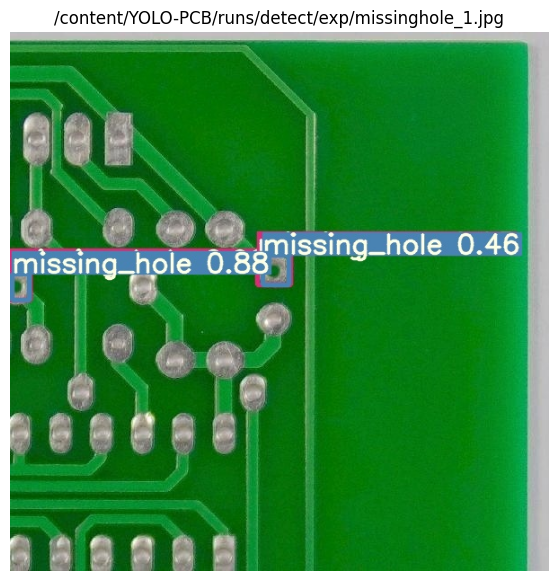

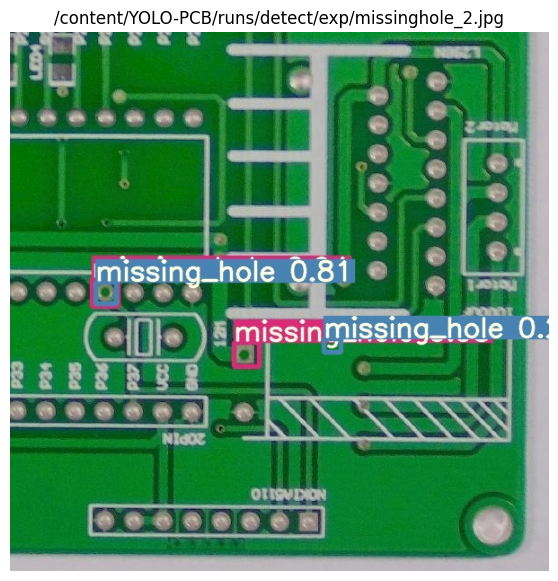

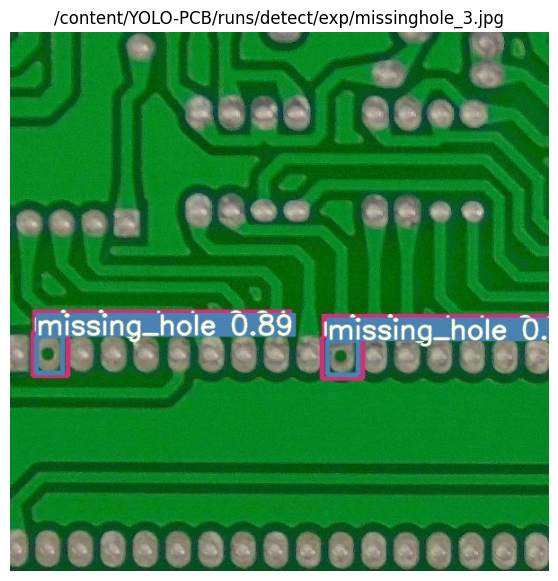

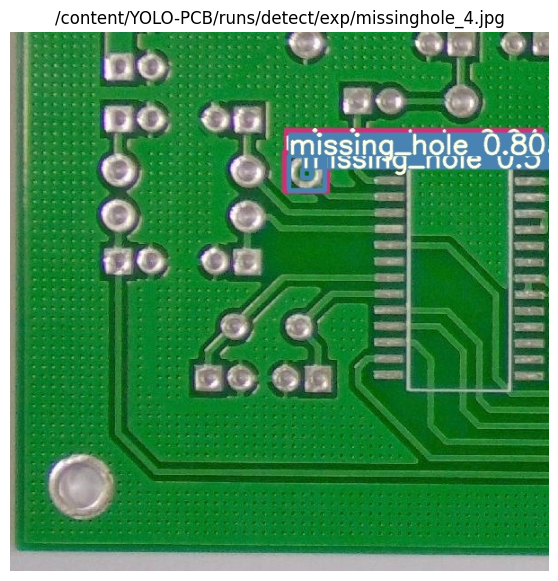

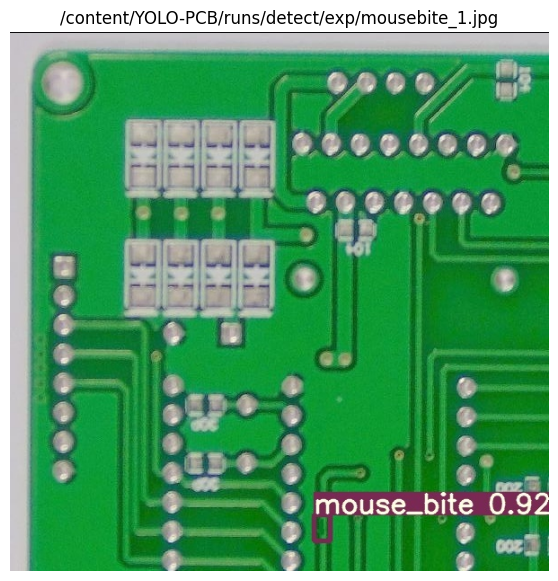

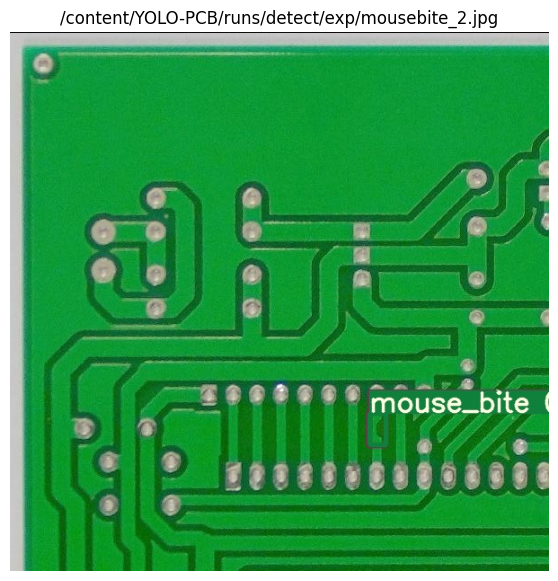

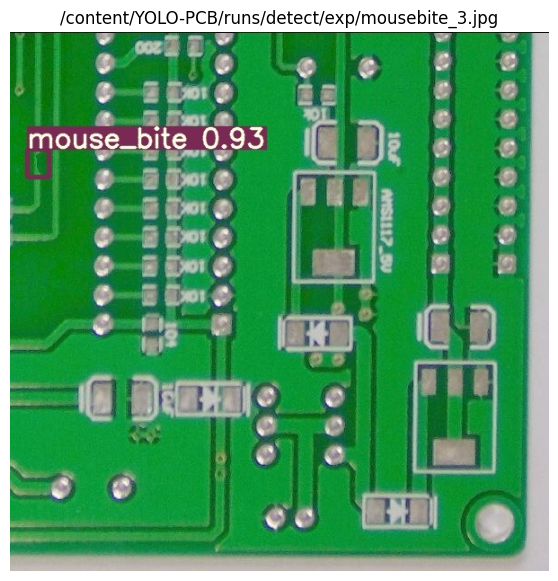

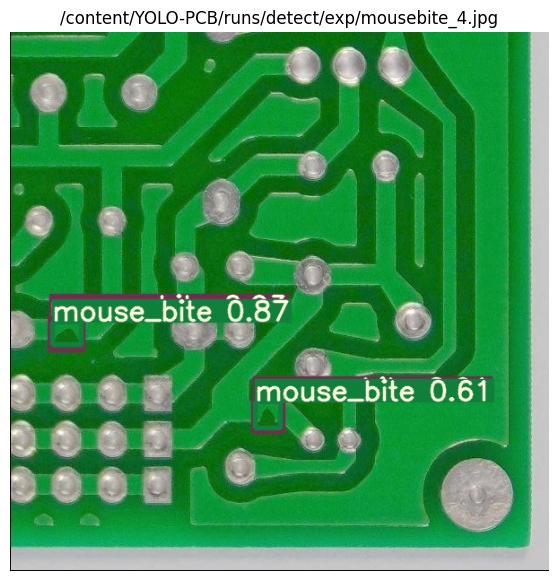

In [6]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

result_images = []
for ext in ["jpg", "jpeg", "png"]:
    result_images.extend(glob.glob(f"/content/YOLO-PCB/runs/detect/exp/**/*.{ext}", recursive=True))
    result_images.extend(glob.glob(f"/content/YOLO-PCB/runs/detect/exp/*.{ext}", recursive=True))

result_images = sorted(list(set(result_images)))

print("검출 결과 이미지 수:", len(result_images))
print("결과 이미지 예시 경로:")
for path in result_images[:10]:
    print(path)

if len(result_images) == 0:
    print("\n결과 이미지가 없습니다. 실제 저장된 파일을 확인합니다.")
    !find /content/YOLO-PCB/runs -type f | head -50
else:
    for img_path in result_images[:8]:
        img = Image.open(img_path)
        plt.figure(figsize=(7, 7))
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path)
        plt.show()

## 8.6 추가: 예측 label txt 파일 확인 및 해석

In [7]:
import glob
import os

label_files = sorted(glob.glob("/content/YOLO-PCB/runs/detect/exp/labels/*.txt"))

print("예측 txt 파일 수:", len(label_files))
for path in label_files[:10]:
    print(path)

if len(label_files) > 0:
    sample_label = label_files[0]
    print("\n[예시 label 파일]")
    print(sample_label)
    with open(sample_label, "r", encoding="utf-8") as f:
        print(f.read())
else:
    print("예측 txt 파일이 없습니다. confidence threshold를 낮춰보거나 detect_log.txt를 확인하세요.")

class_names = [
    "missing hole",
    "mouse bite",
    "open circuit",
    "short circuit",
    "spur",
    "spurious copper"
]

def parse_yolo_label_file(txt_path):
    detections = []
    if not os.path.exists(txt_path):
        return detections

    with open(txt_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue

        class_id = int(float(parts[0]))
        x_center = float(parts[1])
        y_center = float(parts[2])
        width = float(parts[3])
        height = float(parts[4])
        confidence = float(parts[5]) if len(parts) >= 6 else None

        detections.append({
            "class_id": class_id,
            "class_name": class_names[class_id] if class_id < len(class_names) else str(class_id),
            "x_center_ratio": x_center,
            "y_center_ratio": y_center,
            "width_ratio": width,
            "height_ratio": height,
            "confidence": confidence
        })

    return detections

if len(label_files) > 0:
    detections = parse_yolo_label_file(label_files[0])
    print(f"\n해석 대상 파일: {label_files[0]}")
    print(f"검출 결함 수: {len(detections)}")

    for i, det in enumerate(detections, start=1):
        conf_text = f"{det['confidence'] * 100:.1f}%" if det["confidence"] is not None else "없음"
        print(
            f"{i}번 결함: {det['class_name']} | "
            f"중심 위치=({det['x_center_ratio']:.3f}, {det['y_center_ratio']:.3f}) | "
            f"박스 크기=({det['width_ratio']:.3f}, {det['height_ratio']:.3f}) | "
            f"confidence={conf_text}"
        )

예측 txt 파일 수: 19
/content/YOLO-PCB/runs/detect/exp/labels/missinghole_1.txt
/content/YOLO-PCB/runs/detect/exp/labels/missinghole_2.txt
/content/YOLO-PCB/runs/detect/exp/labels/missinghole_3.txt
/content/YOLO-PCB/runs/detect/exp/labels/missinghole_4.txt
/content/YOLO-PCB/runs/detect/exp/labels/mousebite_2.txt
/content/YOLO-PCB/runs/detect/exp/labels/mousebite_4.txt
/content/YOLO-PCB/runs/detect/exp/labels/opencircuit_3.txt
/content/YOLO-PCB/runs/detect/exp/labels/opencircuit_4.txt
/content/YOLO-PCB/runs/detect/exp/labels/short_1.txt
/content/YOLO-PCB/runs/detect/exp/labels/short_2.txt

[예시 label 파일]
/content/YOLO-PCB/runs/detect/exp/labels/missinghole_1.txt
0 0.4925 0.440833 0.0483333 0.055 0.455811
0 0.0191667 0.4725 0.0316667 0.0483333 0.880371


해석 대상 파일: /content/YOLO-PCB/runs/detect/exp/labels/missinghole_1.txt
검출 결함 수: 2
1번 결함: missing hole | 중심 위치=(0.492, 0.441) | 박스 크기=(0.048, 0.055) | confidence=45.6%
2번 결함: missing hole | 중심 위치=(0.019, 0.472) | 박스 크기=(0.032, 0.048) | confidence

## 제출 설명 문장

본 제출 노트북은 논문 저자들이 공개한 YOLO-PCB 저장소와 pretrained weight를 활용하여 Google Colab 환경에서 sample PCB 이미지에 대한 결함 검출 inference를 재현한 코드이다. 최신 Colab 환경과 기존 YOLOv5 코드 간 호환성 문제를 해결하기 위해 `torch.load` 및 `check_requirements()` 관련 부분을 일부 패치하였다.